In [1]:
import os
import json
import math
import re
import sqlite3
import time
from collections import Counter, defaultdict
from typing import Any, TypedDict

import numpy as np
from openai import OpenAI

In [2]:
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
if not OPENAI_API_KEY:
    raise RuntimeError("Set OPENAI_API_KEY before running this notebook: export OPENAI_API_KEY=sk-...")

client = OpenAI(api_key=OPENAI_API_KEY)
EMBED_MODEL = "text-embedding-3-small"
CHAT_MODEL = os.getenv("OPENAI_CHAT_MODEL", "gpt-4o-mini")

print(f"OpenAI ready. Chat model: {CHAT_MODEL}; embedding model: {EMBED_MODEL}")

OpenAI ready. Chat model: gpt-4o-mini; embedding model: text-embedding-3-small


In [3]:
CORPUS = [
    {
        "id": "pods",
        "source": "pods.md",
        "text": "A Kubernetes Pod is the smallest deployable unit. Containers in a Pod share network, storage volumes, and lifecycle. Use kubectl describe pod and kubectl logs to debug Pod behavior.",
    },
    {
        "id": "deployment",
        "source": "deployment.md",
        "text": "A Deployment manages ReplicaSets and rolling updates. Use kubectl rollout status deployment/nginx to watch progress and kubectl rollout undo deployment/nginx to roll back a bad release.",
    },
    {
        "id": "service",
        "source": "service.md",
        "text": "A Service gives stable networking for Pods. ClusterIP is internal, NodePort exposes a port on nodes, and LoadBalancer asks the cloud provider for an external endpoint.",
    },
    {
        "id": "probes",
        "source": "probes.md",
        "text": "Readiness probes decide when a Pod can receive traffic. Liveness probes restart stuck containers. Startup probes protect slow-starting applications from premature restarts.",
    },
    {
        "id": "secrets",
        "source": "secrets.md",
        "text": "Kubernetes Secrets store sensitive values such as passwords, tokens, and keys. Enable encryption at rest, restrict RBAC, and avoid printing secret data in logs.",
    },
    {
        "id": "taints",
        "source": "taints.md",
        "text": "Taints repel Pods from nodes. Tolerations allow selected Pods to schedule onto tainted nodes. A NoSchedule taint blocks Pods that lack a matching toleration.",
    },
    {
        "id": "hpa",
        "source": "hpa.md",
        "text": "The HorizontalPodAutoscaler increases or decreases replicas based on CPU, memory, or custom metrics so an application can handle more traffic automatically.",
    },
]

NOISE_DOCS = [
    {"id": "noise-cache", "source": "cache-paper.md", "text": "Cache-aware matrix multiplication improves locality in CPU memory hierarchies and reduces cache misses."},
    {"id": "noise-graph", "source": "graph-paper.md", "text": "Graph partitioning algorithms optimize edge cuts in distributed computation workloads."},
]

print(f"Inline corpus loaded: {len(CORPUS)} K8s snippets + {len(NOISE_DOCS)} noise snippets")

Inline corpus loaded: 7 K8s snippets + 2 noise snippets


In [4]:
def embed_texts(texts: list[str]) -> list[list[float]]:
    response = client.embeddings.create(model=EMBED_MODEL, input=texts)
    return [item.embedding for item in response.data]


def cosine(a: list[float], b: list[float]) -> float:
    av = np.array(a, dtype=float)
    bv = np.array(b, dtype=float)
    denom = np.linalg.norm(av) * np.linalg.norm(bv)
    return float(np.dot(av, bv) / denom) if denom else 0.0


def dense_search(question: str, docs: list[dict[str, str]], top_k: int = 3) -> list[dict[str, Any]]:
    vectors = embed_texts([question] + [d["text"] for d in docs])
    qv, doc_vectors = vectors[0], vectors[1:]
    ranked = []
    for doc, dv in zip(docs, doc_vectors):
        ranked.append({**doc, "score": cosine(qv, dv)})
    return sorted(ranked, key=lambda d: d["score"], reverse=True)[:top_k]


def answer_with_context(question: str, chunks: list[dict[str, Any]]) -> str:
    context = "\n\n".join(f"SOURCE: {c['source']}\n{c['text']}" for c in chunks)
    messages = [
        {"role": "system", "content": "Answer only from the provided Kubernetes context. Cite source names inline."},
        {"role": "user", "content": f"Context:\n{context}\n\nQuestion: {question}"},
    ]
    response = client.chat.completions.create(model=CHAT_MODEL, messages=messages, temperature=0)
    return response.choices[0].message.content

In [5]:
EXTERNAL_SOURCE = {
    "id": "external-release",
    "source": "external-kubernetes-release-notes.md",
    "text": "External source: Kubernetes 1.34 release information should be checked against current Kubernetes release notes before answering.",
}

In [6]:
def grade_relevance(question: str, chunks: list[dict[str, Any]]) -> dict[str, Any]:
    context = "\n\n".join(c["text"] for c in chunks)
    prompt = f"""Grade whether the context can answer the question.
Return JSON with keys: score (0-1), label (relevant|ambiguous|irrelevant), reason.

Question: {question}
Context: {context}"""
    response = client.chat.completions.create(
        model=CHAT_MODEL,
        messages=[{"role": "user", "content": prompt}],
        response_format={"type": "json_object"},
        temperature=0,
    )
    return json.loads(response.choices[0].message.content)


In [7]:
def fallback_search(question: str) -> list[dict[str, Any]]:
    return [EXTERNAL_SOURCE]

In [8]:

def decide_path(state: dict[str, Any]) -> str:
    return "fallback" if state["grade"]["label"] == "irrelevant" or float(state["grade"]["score"]) < 0.5 else "generate"

In [9]:
from langgraph.graph import StateGraph, END

In [10]:
class CRAGState(TypedDict):
    question: str
    chunks: list[dict[str, Any]]
    grade: dict[str, Any]
    answer: str

In [12]:
def retrieve(state: CRAGState) -> CRAGState:
    return {**state, "chunks": dense_search(state["question"], CORPUS + NOISE_DOCS, top_k=3)}

def grade(state: CRAGState) -> CRAGState:
    return {**state, "grade": grade_relevance(state["question"], state["chunks"])}

def fallback(state: CRAGState) -> CRAGState:
    return {**state, "chunks": fallback_search(state["question"])}

def generate(state: CRAGState) -> CRAGState:
    return {**state, "answer": answer_with_context(state["question"], state["chunks"])}

In [13]:
g = StateGraph(CRAGState)
g.add_node("retrieve", retrieve)
g.add_node("grade", grade)
g.add_node("fallback", fallback)
g.add_node("generate", generate)
g.set_entry_point("retrieve")
g.add_edge("retrieve", "grade")
g.add_conditional_edges("grade", decide_path, {"fallback": "fallback", "generate": "generate"})
g.add_edge("fallback", "generate")
g.add_edge("generate", END)
crag_graph = g.compile()

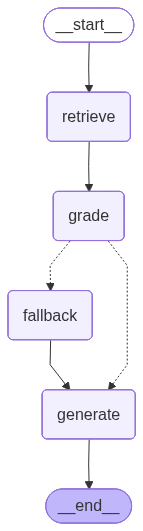

In [14]:
from IPython.display import Image, display


display(Image(crag_graph.get_graph().draw_mermaid_png()))

In [15]:
result = crag_graph.invoke({"question": "What is the latest Kubernetes 1.34 release date?", "chunks": [], "grade": {}, "answer": ""})


In [16]:
result

{'question': 'What is the latest Kubernetes 1.34 release date?',
 'chunks': [{'id': 'external-release',
   'source': 'external-kubernetes-release-notes.md',
   'text': 'External source: Kubernetes 1.34 release information should be checked against current Kubernetes release notes before answering.'}],
 'grade': {'score': 0,
  'label': 'irrelevant',
  'reason': 'The context does not provide any information about the release date of Kubernetes 1.34 or any version of Kubernetes. It focuses on Pods, Deployments, and Secrets without addressing release dates.'},
 'answer': 'The latest Kubernetes 1.34 release date is not specified in the provided context. Please refer to the current Kubernetes release notes for the most accurate information.'}